# Phase 3 — ML Model Development

## BidGuard AI — Risk Classification

### Objective
Develop and evaluate machine learning models for bidder risk-level classification using the ML-ready datasets prepared during Phase 2.

### Target
- `risk_level`

### Risk Classes
- LOW
- MEDIUM
- HIGH

### Model Development Strategy
1. Establish a Logistic Regression baseline
2. Train tree-based models
3. Train ensemble models
4. Compare model performance
5. Evaluate baseline and leakage-controlled feature sets
6. Tune the strongest candidates
7. Select the final model
8. Save the selected model for BidGuard AI integration

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Confusion Matrix

### Important Note
The dataset is synthetic and the target `risk_level` is strongly associated with several compliance-derived features. Therefore, both the full baseline feature set and the restricted leakage-controlled feature set will be evaluated to understand model robustness and potential target leakage.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load processed risk dataset
df = pd.read_csv("../data/processed/risk_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4748, 21)

Columns:
['tender_id', 'bidder_id', 'total_requirements', 'mandatory_requirements', 'compliant_count', 'partially_compliant_count', 'non_compliant_count', 'insufficient_evidence_count', 'compliance_percentage', 'missing_document_count', 'expired_document_count', 'invalid_document_count', 'inconsistency_count', 'evidence_confidence_average', 'mandatory_failure_count', 'financial_requirement_failure', 'experience_requirement_failure', 'registration_requirement_failure', 'authorization_requirement_failure', 'document_quality_score', 'risk_level']


In [2]:
# Target column
target = "risk_level"

# Features used for model development
baseline_features = [
    "total_requirements",
    "mandatory_requirements",
    "compliant_count",
    "partially_compliant_count",
    "non_compliant_count",
    "insufficient_evidence_count",
    "compliance_percentage",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count",
    "mandatory_failure_count",
    "financial_requirement_failure",
    "experience_requirement_failure",
    "registration_requirement_failure",
    "authorization_requirement_failure",
    "evidence_confidence_average",
    "document_quality_score"
]

leakage_controlled_features = [
    "total_requirements",
    "mandatory_requirements",
    "evidence_confidence_average",
    "document_quality_score"
]

# Create feature matrices and target
X_baseline = df[baseline_features].copy()
X_leakage_controlled = df[leakage_controlled_features].copy()
y = df[target].copy()

print("Baseline features:", X_baseline.shape)
print("Leakage-controlled features:", X_leakage_controlled.shape)
print("Target:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Baseline features: (4748, 18)
Leakage-controlled features: (4748, 4)
Target: (4748,)

Target classes:
risk_level
LOW       1899
MEDIUM    1662
HIGH      1187
Name: count, dtype: int64


In [3]:
# Stratified split: 70% train, 15% validation, 15% test

X_base_train, X_base_temp, y_train, y_temp = train_test_split(
    X_baseline,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_base_val, X_base_test, y_val, y_test = train_test_split(
    X_base_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Keep leakage-controlled features aligned to exactly the same records
X_lc_train = X_leakage_controlled.loc[X_base_train.index]
X_lc_val = X_leakage_controlled.loc[X_base_val.index]
X_lc_test = X_leakage_controlled.loc[X_base_test.index]

print("=== Baseline Split ===")
print("Train:", X_base_train.shape)
print("Validation:", X_base_val.shape)
print("Test:", X_base_test.shape)

print("\n=== Leakage-Controlled Split ===")
print("Train:", X_lc_train.shape)
print("Validation:", X_lc_val.shape)
print("Test:", X_lc_test.shape)

print("\n=== Target Split ===")
print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

=== Baseline Split ===
Train: (3323, 18)
Validation: (712, 18)
Test: (713, 18)

=== Leakage-Controlled Split ===
Train: (3323, 4)
Validation: (712, 4)
Test: (713, 4)

=== Target Split ===
Train: (3323,)
Validation: (712,)
Test: (713,)


In [4]:
# Check class distribution across train, validation and test sets

print("=== Train Distribution ===")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\n=== Validation Distribution ===")
print(y_val.value_counts(normalize=True).mul(100).round(2))

print("\n=== Test Distribution ===")
print(y_test.value_counts(normalize=True).mul(100).round(2))

=== Train Distribution ===
risk_level
LOW       39.99
MEDIUM    35.00
HIGH      25.01
Name: proportion, dtype: float64

=== Validation Distribution ===
risk_level
LOW       40.03
MEDIUM    34.97
HIGH      25.00
Name: proportion, dtype: float64

=== Test Distribution ===
risk_level
LOW       39.97
MEDIUM    35.06
HIGH      24.96
Name: proportion, dtype: float64


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Train Logistic Regression baseline model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_base_train, y_train)

# Predictions on validation set
y_val_pred_logistic = logistic_model.predict(X_base_val)

# Calculate validation metrics
logistic_accuracy = accuracy_score(y_val, y_val_pred_logistic)
logistic_precision = precision_score(
    y_val, y_val_pred_logistic, average="macro"
)
logistic_recall = recall_score(
    y_val, y_val_pred_logistic, average="macro"
)
logistic_f1 = f1_score(
    y_val, y_val_pred_logistic, average="macro"
)

print("=== Logistic Regression — Validation Performance ===")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"Macro F1 : {logistic_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_logistic,
        target_names=logistic_model.classes_
    )
)

=== Logistic Regression — Validation Performance ===
Accuracy : 0.9719
Precision: 0.9735
Recall   : 0.9728
Macro F1 : 0.9732

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.99      0.98      0.99       178
         LOW       0.97      0.98      0.97       285
      MEDIUM       0.96      0.96      0.96       249

    accuracy                           0.97       712
   macro avg       0.97      0.97      0.97       712
weighted avg       0.97      0.97      0.97       712



c:\Users\Siddh\Desktop\BidGuard-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
from sklearn.preprocessing import StandardScaler

# Create scaler
baseline_scaler = StandardScaler()

# Fit ONLY on training data
X_base_train_scaled = baseline_scaler.fit_transform(X_base_train)

# Transform validation and test data
X_base_val_scaled = baseline_scaler.transform(X_base_val)
X_base_test_scaled = baseline_scaler.transform(X_base_test)

# Convert back to DataFrames and preserve feature names
X_base_train_scaled_df = pd.DataFrame(
    X_base_train_scaled,
    columns=baseline_features,
    index=X_base_train.index
)

X_base_val_scaled_df = pd.DataFrame(
    X_base_val_scaled,
    columns=baseline_features,
    index=X_base_val.index
)

X_base_test_scaled_df = pd.DataFrame(
    X_base_test_scaled,
    columns=baseline_features,
    index=X_base_test.index
)

print("Scaled Train:", X_base_train_scaled_df.shape)
print("Scaled Validation:", X_base_val_scaled_df.shape)
print("Scaled Test:", X_base_test_scaled_df.shape)

print("\nMissing values:")
print("Train:", X_base_train_scaled_df.isna().sum().sum())
print("Validation:", X_base_val_scaled_df.isna().sum().sum())
print("Test:", X_base_test_scaled_df.isna().sum().sum())

Scaled Train: (3323, 18)
Scaled Validation: (712, 18)
Scaled Test: (713, 18)

Missing values:
Train: 0
Validation: 0
Test: 0


In [7]:
# Train Logistic Regression on scaled features

logistic_scaled_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_scaled_model.fit(
    X_base_train_scaled_df,
    y_train
)

# Validation predictions
y_val_pred_logistic_scaled = logistic_scaled_model.predict(
    X_base_val_scaled_df
)

# Calculate validation metrics
logistic_scaled_accuracy = accuracy_score(
    y_val,
    y_val_pred_logistic_scaled
)

logistic_scaled_precision = precision_score(
    y_val,
    y_val_pred_logistic_scaled,
    average="macro"
)

logistic_scaled_recall = recall_score(
    y_val,
    y_val_pred_logistic_scaled,
    average="macro"
)

logistic_scaled_f1 = f1_score(
    y_val,
    y_val_pred_logistic_scaled,
    average="macro"
)

print("=== Scaled Logistic Regression — Validation Performance ===")
print(f"Accuracy : {logistic_scaled_accuracy:.4f}")
print(f"Precision: {logistic_scaled_precision:.4f}")
print(f"Recall   : {logistic_scaled_recall:.4f}")
print(f"Macro F1 : {logistic_scaled_f1:.4f}")

print("\nIterations used:", logistic_scaled_model.n_iter_[0])

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_logistic_scaled,
        target_names=logistic_scaled_model.classes_
    )
)

=== Scaled Logistic Regression — Validation Performance ===
Accuracy : 0.9874
Precision: 0.9886
Recall   : 0.9869
Macro F1 : 0.9877

Iterations used: 31

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99       178
         LOW       0.99      0.99      0.99       285
      MEDIUM       0.98      0.99      0.98       249

    accuracy                           0.99       712
   macro avg       0.99      0.99      0.99       712
weighted avg       0.99      0.99      0.99       712



In [8]:
# Confusion Matrix for Logistic Regression

logistic_cm = confusion_matrix(
    y_val,
    y_val_pred_logistic_scaled,
    labels=logistic_scaled_model.classes_
)

print("Classes:", logistic_scaled_model.classes_)
print("\nConfusion Matrix:")
print(logistic_cm)

Classes: ['HIGH' 'LOW' 'MEDIUM']

Confusion Matrix:
[[175   0   3]
 [  0 282   3]
 [  0   3 246]]


In [9]:
# Store Logistic Regression validation results

model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Feature Set": "Baseline",
    "Accuracy": logistic_scaled_accuracy,
    "Precision": logistic_scaled_precision,
    "Recall": logistic_scaled_recall,
    "Macro F1": logistic_scaled_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877


In [10]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_base_train,
    y_train
)

# Validation predictions
y_val_pred_tree = decision_tree_model.predict(
    X_base_val
)

# Validation metrics
tree_accuracy = accuracy_score(
    y_val,
    y_val_pred_tree
)

tree_precision = precision_score(
    y_val,
    y_val_pred_tree,
    average="macro"
)

tree_recall = recall_score(
    y_val,
    y_val_pred_tree,
    average="macro"
)

tree_f1 = f1_score(
    y_val,
    y_val_pred_tree,
    average="macro"
)

print("=== Decision Tree — Validation Performance ===")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"Macro F1 : {tree_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_tree,
        target_names=decision_tree_model.classes_
    )
)

=== Decision Tree — Validation Performance ===
Accuracy : 0.9452
Precision: 0.9475
Recall   : 0.9457
Macro F1 : 0.9466

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.97      0.96      0.96       178
         LOW       0.95      0.95      0.95       285
      MEDIUM       0.92      0.93      0.92       249

    accuracy                           0.95       712
   macro avg       0.95      0.95      0.95       712
weighted avg       0.95      0.95      0.95       712



In [11]:
# Add Decision Tree results to comparison table

model_results.append({
    "Model": "Decision Tree",
    "Feature Set": "Baseline",
    "Accuracy": tree_accuracy,
    "Precision": tree_precision,
    "Recall": tree_recall,
    "Macro F1": tree_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))


                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877
1        Decision Tree    Baseline    0.9452     0.9475  0.9457    0.9466


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_base_train,
    y_train
)

# Validation predictions
y_val_pred_rf = random_forest_model.predict(
    X_base_val
)

# Validation metrics
rf_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

rf_precision = precision_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

rf_recall = recall_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

rf_f1 = f1_score(
    y_val,
    y_val_pred_rf,
    average="macro"
)

print("=== Random Forest — Validation Performance ===")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"Macro F1 : {rf_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=random_forest_model.classes_
    )
)

=== Random Forest — Validation Performance ===
Accuracy : 0.9551
Precision: 0.9593
Recall   : 0.9539
Macro F1 : 0.9564

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.99      0.95      0.97       178
         LOW       0.96      0.97      0.96       285
      MEDIUM       0.93      0.94      0.94       249

    accuracy                           0.96       712
   macro avg       0.96      0.95      0.96       712
weighted avg       0.96      0.96      0.96       712



In [13]:
# Add Random Forest results to comparison table

model_results.append({
    "Model": "Random Forest",
    "Feature Set": "Baseline",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "Macro F1": rf_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877
1        Decision Tree    Baseline    0.9452     0.9475  0.9457    0.9466
2        Random Forest    Baseline    0.9551     0.9593  0.9539    0.9564


In [14]:
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_base_train,
    y_train
)

# Validation predictions
y_val_pred_gb = gradient_boosting_model.predict(
    X_base_val
)

# Validation metrics
gb_accuracy = accuracy_score(
    y_val,
    y_val_pred_gb
)

gb_precision = precision_score(
    y_val,
    y_val_pred_gb,
    average="macro"
)

gb_recall = recall_score(
    y_val,
    y_val_pred_gb,
    average="macro"
)

gb_f1 = f1_score(
    y_val,
    y_val_pred_gb,
    average="macro"
)

print("=== Gradient Boosting — Validation Performance ===")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"Macro F1 : {gb_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_gb,
        target_names=gradient_boosting_model.classes_
    )
)

=== Gradient Boosting — Validation Performance ===
Accuracy : 0.9649
Precision: 0.9681
Recall   : 0.9631
Macro F1 : 0.9654

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.99      0.96      0.97       178
         LOW       0.96      0.98      0.97       285
      MEDIUM       0.95      0.95      0.95       249

    accuracy                           0.96       712
   macro avg       0.97      0.96      0.97       712
weighted avg       0.97      0.96      0.96       712



In [15]:
# Add Gradient Boosting results to comparison table

model_results.append({
    "Model": "Gradient Boosting",
    "Feature Set": "Baseline",
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "Macro F1": gb_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877
1        Decision Tree    Baseline    0.9452     0.9475  0.9457    0.9466
2        Random Forest    Baseline    0.9551     0.9593  0.9539    0.9564
3    Gradient Boosting    Baseline    0.9649     0.9681  0.9631    0.9654


In [16]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.4.1
XGBoost is available.


In [18]:
from xgboost import XGBClassifier

# Encode target labels for XGBoost
xgb_label_encoder = LabelEncoder()

y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_val_xgb = xgb_label_encoder.transform(y_val)

print("XGBoost target mapping:")
for class_name, encoded_value in zip(
    xgb_label_encoder.classes_,
    xgb_label_encoder.transform(xgb_label_encoder.classes_)
):
    print(f"{class_name} -> {encoded_value}")

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_base_train,
    y_train_xgb
)

# Validation predictions
y_val_pred_xgb_encoded = xgb_model.predict(
    X_base_val
)

# Convert predictions back to original class names
y_val_pred_xgb = xgb_label_encoder.inverse_transform(
    y_val_pred_xgb_encoded.astype(int)
)

# Validation metrics
xgb_accuracy = accuracy_score(
    y_val,
    y_val_pred_xgb
)

xgb_precision = precision_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

xgb_recall = recall_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

xgb_f1 = f1_score(
    y_val,
    y_val_pred_xgb,
    average="macro"
)

print("\n=== XGBoost — Validation Performance ===")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"Macro F1 : {xgb_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_xgb,
        labels=xgb_label_encoder.classes_
    )
)

XGBoost target mapping:
HIGH -> 0
LOW -> 1
MEDIUM -> 2

=== XGBoost — Validation Performance ===
Accuracy : 0.9621
Precision: 0.9660
Recall   : 0.9603
Macro F1 : 0.9629

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.99      0.96      0.97       178
         LOW       0.95      0.99      0.97       285
      MEDIUM       0.95      0.94      0.95       249

    accuracy                           0.96       712
   macro avg       0.97      0.96      0.96       712
weighted avg       0.96      0.96      0.96       712



In [19]:
# Add XGBoost results to comparison table

model_results.append({
    "Model": "XGBoost",
    "Feature Set": "Baseline",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "Macro F1": xgb_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877
1        Decision Tree    Baseline    0.9452     0.9475  0.9457    0.9466
2        Random Forest    Baseline    0.9551     0.9593  0.9539    0.9564
3    Gradient Boosting    Baseline    0.9649     0.9681  0.9631    0.9654
4              XGBoost    Baseline    0.9621     0.9660  0.9603    0.9629


In [20]:
# Prepare leakage-controlled training and validation data

X_lc_train = X_leakage_controlled.loc[X_base_train.index]
X_lc_val = X_leakage_controlled.loc[X_base_val.index]
X_lc_test = X_leakage_controlled.loc[X_base_test.index]

print("Leakage-Controlled Features:")
print(leakage_controlled_features)

print("\nTrain:", X_lc_train.shape)
print("Validation:", X_lc_val.shape)
print("Test:", X_lc_test.shape)

Leakage-Controlled Features:
['total_requirements', 'mandatory_requirements', 'evidence_confidence_average', 'document_quality_score']

Train: (3323, 4)
Validation: (712, 4)
Test: (713, 4)


In [21]:
# Scale leakage-controlled features
lc_scaler = StandardScaler()

X_lc_train_scaled = lc_scaler.fit_transform(X_lc_train)
X_lc_val_scaled = lc_scaler.transform(X_lc_val)
X_lc_test_scaled = lc_scaler.transform(X_lc_test)

# Preserve feature names
X_lc_train_scaled_df = pd.DataFrame(
    X_lc_train_scaled,
    columns=leakage_controlled_features,
    index=X_lc_train.index
)

X_lc_val_scaled_df = pd.DataFrame(
    X_lc_val_scaled,
    columns=leakage_controlled_features,
    index=X_lc_val.index
)

X_lc_test_scaled_df = pd.DataFrame(
    X_lc_test_scaled,
    columns=leakage_controlled_features,
    index=X_lc_test.index
)

# Train Logistic Regression
lc_logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lc_logistic_model.fit(
    X_lc_train_scaled_df,
    y_train
)

# Validation predictions
y_val_pred_lc_logistic = lc_logistic_model.predict(
    X_lc_val_scaled_df
)

# Metrics
lc_logistic_accuracy = accuracy_score(
    y_val,
    y_val_pred_lc_logistic
)

lc_logistic_precision = precision_score(
    y_val,
    y_val_pred_lc_logistic,
    average="macro"
)

lc_logistic_recall = recall_score(
    y_val,
    y_val_pred_lc_logistic,
    average="macro"
)

lc_logistic_f1 = f1_score(
    y_val,
    y_val_pred_lc_logistic,
    average="macro"
)

print("=== Leakage-Controlled Logistic Regression ===")
print(f"Accuracy : {lc_logistic_accuracy:.4f}")
print(f"Precision: {lc_logistic_precision:.4f}")
print(f"Recall   : {lc_logistic_recall:.4f}")
print(f"Macro F1 : {lc_logistic_f1:.4f}")

print("\nIterations used:", lc_logistic_model.n_iter_[0])

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_lc_logistic,
        target_names=lc_logistic_model.classes_
    )
)

=== Leakage-Controlled Logistic Regression ===
Accuracy : 0.5098
Precision: 0.5666
Recall   : 0.4953
Macro F1 : 0.4896

Iterations used: 10

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.82      0.50      0.62       178
         LOW       0.46      0.79      0.58       285
      MEDIUM       0.42      0.19      0.26       249

    accuracy                           0.51       712
   macro avg       0.57      0.50      0.49       712
weighted avg       0.54      0.51      0.48       712



In [22]:
# Add leakage-controlled Logistic Regression results

model_results.append({
    "Model": "Logistic Regression",
    "Feature Set": "Leakage-Controlled",
    "Accuracy": lc_logistic_accuracy,
    "Precision": lc_logistic_precision,
    "Recall": lc_logistic_recall,
    "Macro F1": lc_logistic_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model         Feature Set  Accuracy  Precision  Recall  \
0  Logistic Regression            Baseline    0.9874     0.9886  0.9869   
1        Decision Tree            Baseline    0.9452     0.9475  0.9457   
2        Random Forest            Baseline    0.9551     0.9593  0.9539   
3    Gradient Boosting            Baseline    0.9649     0.9681  0.9631   
4              XGBoost            Baseline    0.9621     0.9660  0.9603   
5  Logistic Regression  Leakage-Controlled    0.5098     0.5666  0.4953   

   Macro F1  
0    0.9877  
1    0.9466  
2    0.9564  
3    0.9654  
4    0.9629  
5    0.4896  


In [23]:
# Train Decision Tree using leakage-controlled features

lc_decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

lc_decision_tree_model.fit(
    X_lc_train,
    y_train
)

# Validation predictions
y_val_pred_lc_tree = lc_decision_tree_model.predict(
    X_lc_val
)

# Metrics
lc_tree_accuracy = accuracy_score(
    y_val,
    y_val_pred_lc_tree
)

lc_tree_precision = precision_score(
    y_val,
    y_val_pred_lc_tree,
    average="macro"
)

lc_tree_recall = recall_score(
    y_val,
    y_val_pred_lc_tree,
    average="macro"
)

lc_tree_f1 = f1_score(
    y_val,
    y_val_pred_lc_tree,
    average="macro"
)

print("=== Leakage-Controlled Decision Tree ===")
print(f"Accuracy : {lc_tree_accuracy:.4f}")
print(f"Precision: {lc_tree_precision:.4f}")
print(f"Recall   : {lc_tree_recall:.4f}")
print(f"Macro F1 : {lc_tree_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_lc_tree,
        target_names=lc_decision_tree_model.classes_
    )
)

=== Leakage-Controlled Decision Tree ===
Accuracy : 0.4607
Precision: 0.4661
Recall   : 0.4692
Macro F1 : 0.4674

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.52      0.54      0.53       178
         LOW       0.48      0.45      0.46       285
      MEDIUM       0.40      0.41      0.41       249

    accuracy                           0.46       712
   macro avg       0.47      0.47      0.47       712
weighted avg       0.46      0.46      0.46       712



In [24]:
# Add leakage-controlled Decision Tree results

model_results.append({
    "Model": "Decision Tree",
    "Feature Set": "Leakage-Controlled",
    "Accuracy": lc_tree_accuracy,
    "Precision": lc_tree_precision,
    "Recall": lc_tree_recall,
    "Macro F1": lc_tree_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model         Feature Set  Accuracy  Precision  Recall  \
0  Logistic Regression            Baseline    0.9874     0.9886  0.9869   
1        Decision Tree            Baseline    0.9452     0.9475  0.9457   
2        Random Forest            Baseline    0.9551     0.9593  0.9539   
3    Gradient Boosting            Baseline    0.9649     0.9681  0.9631   
4              XGBoost            Baseline    0.9621     0.9660  0.9603   
5  Logistic Regression  Leakage-Controlled    0.5098     0.5666  0.4953   
6        Decision Tree  Leakage-Controlled    0.4607     0.4661  0.4692   

   Macro F1  
0    0.9877  
1    0.9466  
2    0.9564  
3    0.9654  
4    0.9629  
5    0.4896  
6    0.4674  


In [25]:
# Train Random Forest using leakage-controlled features

lc_random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

lc_random_forest_model.fit(
    X_lc_train,
    y_train
)

# Validation predictions
y_val_pred_lc_rf = lc_random_forest_model.predict(
    X_lc_val
)

# Metrics
lc_rf_accuracy = accuracy_score(
    y_val,
    y_val_pred_lc_rf
)

lc_rf_precision = precision_score(
    y_val,
    y_val_pred_lc_rf,
    average="macro"
)

lc_rf_recall = recall_score(
    y_val,
    y_val_pred_lc_rf,
    average="macro"
)

lc_rf_f1 = f1_score(
    y_val,
    y_val_pred_lc_rf,
    average="macro"
)

print("=== Leakage-Controlled Random Forest ===")
print(f"Accuracy : {lc_rf_accuracy:.4f}")
print(f"Precision: {lc_rf_precision:.4f}")
print(f"Recall   : {lc_rf_recall:.4f}")
print(f"Macro F1 : {lc_rf_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_lc_rf,
        target_names=lc_random_forest_model.classes_
    )
)

=== Leakage-Controlled Random Forest ===
Accuracy : 0.5014
Precision: 0.5320
Recall   : 0.5021
Macro F1 : 0.5129

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.69      0.53      0.60       178
         LOW       0.49      0.55      0.52       285
      MEDIUM       0.42      0.42      0.42       249

    accuracy                           0.50       712
   macro avg       0.53      0.50      0.51       712
weighted avg       0.51      0.50      0.50       712



In [26]:
# Add leakage-controlled Random Forest results

model_results.append({
    "Model": "Random Forest",
    "Feature Set": "Leakage-Controlled",
    "Accuracy": lc_rf_accuracy,
    "Precision": lc_rf_precision,
    "Recall": lc_rf_recall,
    "Macro F1": lc_rf_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model         Feature Set  Accuracy  Precision  Recall  \
0  Logistic Regression            Baseline    0.9874     0.9886  0.9869   
1        Decision Tree            Baseline    0.9452     0.9475  0.9457   
2        Random Forest            Baseline    0.9551     0.9593  0.9539   
3    Gradient Boosting            Baseline    0.9649     0.9681  0.9631   
4              XGBoost            Baseline    0.9621     0.9660  0.9603   
5  Logistic Regression  Leakage-Controlled    0.5098     0.5666  0.4953   
6        Decision Tree  Leakage-Controlled    0.4607     0.4661  0.4692   
7        Random Forest  Leakage-Controlled    0.5014     0.5320  0.5021   

   Macro F1  
0    0.9877  
1    0.9466  
2    0.9564  
3    0.9654  
4    0.9629  
5    0.4896  
6    0.4674  
7    0.5129  


In [27]:
# Train Gradient Boosting using leakage-controlled features

lc_gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

lc_gradient_boosting_model.fit(
    X_lc_train,
    y_train
)

# Validation predictions
y_val_pred_lc_gb = lc_gradient_boosting_model.predict(
    X_lc_val
)

# Metrics
lc_gb_accuracy = accuracy_score(
    y_val,
    y_val_pred_lc_gb
)

lc_gb_precision = precision_score(
    y_val,
    y_val_pred_lc_gb,
    average="macro"
)

lc_gb_recall = recall_score(
    y_val,
    y_val_pred_lc_gb,
    average="macro"
)

lc_gb_f1 = f1_score(
    y_val,
    y_val_pred_lc_gb,
    average="macro"
)

print("=== Leakage-Controlled Gradient Boosting ===")
print(f"Accuracy : {lc_gb_accuracy:.4f}")
print(f"Precision: {lc_gb_precision:.4f}")
print(f"Recall   : {lc_gb_recall:.4f}")
print(f"Macro F1 : {lc_gb_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_lc_gb,
        target_names=lc_gradient_boosting_model.classes_
    )
)

=== Leakage-Controlled Gradient Boosting ===
Accuracy : 0.5239
Precision: 0.6017
Recall   : 0.5161
Macro F1 : 0.5373

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.88      0.49      0.63       178
         LOW       0.48      0.63      0.54       285
      MEDIUM       0.45      0.43      0.44       249

    accuracy                           0.52       712
   macro avg       0.60      0.52      0.54       712
weighted avg       0.57      0.52      0.53       712



In [28]:
# Add leakage-controlled Gradient Boosting results

model_results.append({
    "Model": "Gradient Boosting",
    "Feature Set": "Leakage-Controlled",
    "Accuracy": lc_gb_accuracy,
    "Precision": lc_gb_precision,
    "Recall": lc_gb_recall,
    "Macro F1": lc_gb_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))

                 Model         Feature Set  Accuracy  Precision  Recall  \
0  Logistic Regression            Baseline    0.9874     0.9886  0.9869   
1        Decision Tree            Baseline    0.9452     0.9475  0.9457   
2        Random Forest            Baseline    0.9551     0.9593  0.9539   
3    Gradient Boosting            Baseline    0.9649     0.9681  0.9631   
4              XGBoost            Baseline    0.9621     0.9660  0.9603   
5  Logistic Regression  Leakage-Controlled    0.5098     0.5666  0.4953   
6        Decision Tree  Leakage-Controlled    0.4607     0.4661  0.4692   
7        Random Forest  Leakage-Controlled    0.5014     0.5320  0.5021   
8    Gradient Boosting  Leakage-Controlled    0.5239     0.6017  0.5161   

   Macro F1  
0    0.9877  
1    0.9466  
2    0.9564  
3    0.9654  
4    0.9629  
5    0.4896  
6    0.4674  
7    0.5129  
8    0.5373  


In [29]:
# Train XGBoost using leakage-controlled features

lc_xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

lc_xgb_model.fit(
    X_lc_train,
    y_train_xgb
)

# Validation predictions
y_val_pred_lc_xgb_encoded = lc_xgb_model.predict(
    X_lc_val
)

# Convert numeric predictions back to original labels
y_val_pred_lc_xgb = xgb_label_encoder.inverse_transform(
    y_val_pred_lc_xgb_encoded.astype(int)
)

# Metrics
lc_xgb_accuracy = accuracy_score(
    y_val,
    y_val_pred_lc_xgb
)

lc_xgb_precision = precision_score(
    y_val,
    y_val_pred_lc_xgb,
    average="macro"
)

lc_xgb_recall = recall_score(
    y_val,
    y_val_pred_lc_xgb,
    average="macro"
)

lc_xgb_f1 = f1_score(
    y_val,
    y_val_pred_lc_xgb,
    average="macro"
)

print("=== Leakage-Controlled XGBoost ===")
print(f"Accuracy : {lc_xgb_accuracy:.4f}")
print(f"Precision: {lc_xgb_precision:.4f}")
print(f"Recall   : {lc_xgb_recall:.4f}")
print(f"Macro F1 : {lc_xgb_f1:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_val,
        y_val_pred_lc_xgb,
        target_names=xgb_label_encoder.classes_
    )
)

=== Leakage-Controlled XGBoost ===
Accuracy : 0.5183
Precision: 0.6061
Recall   : 0.5116
Macro F1 : 0.5350

=== Classification Report ===
              precision    recall  f1-score   support

        HIGH       0.92      0.50      0.65       178
         LOW       0.47      0.62      0.54       285
      MEDIUM       0.43      0.41      0.42       249

    accuracy                           0.52       712
   macro avg       0.61      0.51      0.53       712
weighted avg       0.57      0.52      0.52       712



In [30]:
# Add leakage-controlled XGBoost results

model_results.append({
    "Model": "XGBoost",
    "Feature Set": "Leakage-Controlled",
    "Accuracy": lc_xgb_accuracy,
    "Precision": lc_xgb_precision,
    "Recall": lc_xgb_recall,
    "Macro F1": lc_xgb_f1
})

results_df = pd.DataFrame(model_results)

print(results_df.round(4))


                 Model         Feature Set  Accuracy  Precision  Recall  \
0  Logistic Regression            Baseline    0.9874     0.9886  0.9869   
1        Decision Tree            Baseline    0.9452     0.9475  0.9457   
2        Random Forest            Baseline    0.9551     0.9593  0.9539   
3    Gradient Boosting            Baseline    0.9649     0.9681  0.9631   
4              XGBoost            Baseline    0.9621     0.9660  0.9603   
5  Logistic Regression  Leakage-Controlled    0.5098     0.5666  0.4953   
6        Decision Tree  Leakage-Controlled    0.4607     0.4661  0.4692   
7        Random Forest  Leakage-Controlled    0.5014     0.5320  0.5021   
8    Gradient Boosting  Leakage-Controlled    0.5239     0.6017  0.5161   
9              XGBoost  Leakage-Controlled    0.5183     0.6061  0.5116   

   Macro F1  
0    0.9877  
1    0.9466  
2    0.9564  
3    0.9654  
4    0.9629  
5    0.4896  
6    0.4674  
7    0.5129  
8    0.5373  
9    0.5350  


In [31]:
# Compare baseline and leakage-controlled performance

comparison_df = results_df.pivot(
    index="Model",
    columns="Feature Set",
    values="Macro F1"
).reset_index()

comparison_df["F1 Difference"] = (
    comparison_df["Baseline"]
    - comparison_df["Leakage-Controlled"]
)

print("=== Baseline vs Leakage-Controlled Macro F1 ===")
print(comparison_df.round(4))

=== Baseline vs Leakage-Controlled Macro F1 ===
Feature Set                Model  Baseline  Leakage-Controlled  F1 Difference
0                  Decision Tree    0.9466              0.4674         0.4792
1              Gradient Boosting    0.9654              0.5373         0.4282
2            Logistic Regression    0.9877              0.4896         0.4981
3                  Random Forest    0.9564              0.5129         0.4435
4                        XGBoost    0.9629              0.5350         0.4279


In [32]:
# Compare baseline models using validation Macro F1

baseline_comparison_df = (
    results_df[
        results_df["Feature Set"] == "Baseline"
    ]
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

print("=== Baseline Model Comparison ===")
print(baseline_comparison_df.round(4))

=== Baseline Model Comparison ===
                 Model Feature Set  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    Baseline    0.9874     0.9886  0.9869    0.9877
1    Gradient Boosting    Baseline    0.9649     0.9681  0.9631    0.9654
2              XGBoost    Baseline    0.9621     0.9660  0.9603    0.9629
3        Random Forest    Baseline    0.9551     0.9593  0.9539    0.9564
4        Decision Tree    Baseline    0.9452     0.9475  0.9457    0.9466


In [33]:
# Hyperparameter tuning for Logistic Regression

logistic_c_values = [0.01, 0.1, 1, 10, 100]

logistic_tuning_results = []

for c_value in logistic_c_values:
    model = LogisticRegression(
        C=c_value,
        max_iter=2000,
        random_state=42
    )
    
    model.fit(
        X_base_train_scaled_df,
        y_train
    )
    
    y_val_pred = model.predict(
        X_base_val_scaled_df
    )
    
    logistic_tuning_results.append({
        "C": c_value,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(
            y_val, y_val_pred, average="macro"
        ),
        "Recall": recall_score(
            y_val, y_val_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_val, y_val_pred, average="macro"
        )
    })

logistic_tuning_df = pd.DataFrame(
    logistic_tuning_results
)

print("=== Logistic Regression Hyperparameter Tuning ===")
print(logistic_tuning_df.round(4))

=== Logistic Regression Hyperparameter Tuning ===
        C  Accuracy  Precision  Recall  Macro F1
0    0.01    0.9340     0.9407  0.9303    0.9348
1    0.10    0.9719     0.9741  0.9696    0.9717
2    1.00    0.9874     0.9886  0.9869    0.9877
3   10.00    0.9874     0.9871  0.9869    0.9870
4  100.00    0.9803     0.9809  0.9798    0.9803


In [34]:
# Select best Logistic Regression configuration

best_logistic_row = logistic_tuning_df.loc[
    logistic_tuning_df["Macro F1"].idxmax()
]

best_logistic_c = best_logistic_row["C"]
best_logistic_f1 = best_logistic_row["Macro F1"]

print("=== Best Logistic Regression Configuration ===")
print(f"Best C      : {best_logistic_c}")
print(f"Validation F1: {best_logistic_f1:.4f}")

=== Best Logistic Regression Configuration ===
Best C      : 1.0
Validation F1: 0.9877


In [35]:
# Hyperparameter tuning for Gradient Boosting

gb_parameter_sets = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.10,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4
    }
]

gb_tuning_results = []

for params in gb_parameter_sets:
    model = GradientBoostingClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )
    
    model.fit(
        X_base_train,
        y_train
    )
    
    y_val_pred = model.predict(
        X_base_val
    )
    
    gb_tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(
            y_val, y_val_pred, average="macro"
        ),
        "Recall": recall_score(
            y_val, y_val_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_val, y_val_pred, average="macro"
        )
    })

gb_tuning_df = pd.DataFrame(gb_tuning_results)

print("=== Gradient Boosting Hyperparameter Tuning ===")
print(gb_tuning_df.round(4))

=== Gradient Boosting Hyperparameter Tuning ===
   n_estimators  learning_rate  max_depth  Accuracy  Precision  Recall  \
0           100           0.05          2    0.9424     0.9474  0.9416   
1           200           0.05          3    0.9649     0.9681  0.9631   
2           300           0.05          3    0.9621     0.9657  0.9611   
3           200           0.10          3    0.9621     0.9656  0.9613   
4           200           0.05          4    0.9621     0.9656  0.9613   

   Macro F1  
0    0.9442  
1    0.9654  
2    0.9633  
3    0.9633  
4    0.9633  


In [36]:
# Select best Gradient Boosting configuration

best_gb_row = gb_tuning_df.loc[
    gb_tuning_df["Macro F1"].idxmax()
]

best_gb_params = {
    "n_estimators": int(best_gb_row["n_estimators"]),
    "learning_rate": best_gb_row["learning_rate"],
    "max_depth": int(best_gb_row["max_depth"])
}

best_gb_f1 = best_gb_row["Macro F1"]

print("=== Best Gradient Boosting Configuration ===")
print(f"Parameters : {best_gb_params}")
print(f"Validation F1: {best_gb_f1:.4f}")

=== Best Gradient Boosting Configuration ===
Parameters : {'n_estimators': 200, 'learning_rate': np.float64(0.05), 'max_depth': 3}
Validation F1: 0.9654


In [37]:
# Hyperparameter tuning for XGBoost

xgb_parameter_sets = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.10,
        "max_depth": 4
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 5
    }
]

xgb_tuning_results = []

for params in xgb_parameter_sets:

    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_base_train,
        y_train_xgb
    )

    y_val_pred_encoded = model.predict(
        X_base_val
    )

    y_val_pred = xgb_label_encoder.inverse_transform(
        y_val_pred_encoded.astype(int)
    )

    xgb_tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(
            y_val, y_val_pred, average="macro"
        ),
        "Recall": recall_score(
            y_val, y_val_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_val, y_val_pred, average="macro"
        )
    })

xgb_tuning_df = pd.DataFrame(xgb_tuning_results)

print("=== XGBoost Hyperparameter Tuning ===")
print(xgb_tuning_df.round(4))

=== XGBoost Hyperparameter Tuning ===
   n_estimators  learning_rate  max_depth  Accuracy  Precision  Recall  \
0           100           0.05          3    0.9466     0.9520  0.9458   
1           200           0.05          4    0.9621     0.9660  0.9603   
2           300           0.05          4    0.9649     0.9684  0.9642   
3           200           0.10          4    0.9663     0.9693  0.9651   
4           200           0.05          5    0.9593     0.9625  0.9579   

   Macro F1  
0    0.9484  
1    0.9629  
2    0.9661  
3    0.9671  
4    0.9600  


In [38]:
# Select best XGBoost configuration

best_xgb_row = xgb_tuning_df.loc[
    xgb_tuning_df["Macro F1"].idxmax()
]

best_xgb_params = {
    "n_estimators": int(best_xgb_row["n_estimators"]),
    "learning_rate": best_xgb_row["learning_rate"],
    "max_depth": int(best_xgb_row["max_depth"])
}

best_xgb_f1 = best_xgb_row["Macro F1"]

print("=== Best XGBoost Configuration ===")
print(f"Parameters : {best_xgb_params}")
print(f"Validation F1: {best_xgb_f1:.4f}")

=== Best XGBoost Configuration ===
Parameters : {'n_estimators': 200, 'learning_rate': np.float64(0.1), 'max_depth': 4}
Validation F1: 0.9671


In [39]:
# Compare selected tuned model configurations

tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best Parameters": f"C={best_logistic_c}",
        "Validation Macro F1": best_logistic_f1
    },
    {
        "Model": "Gradient Boosting",
        "Best Parameters": str(best_gb_params),
        "Validation Macro F1": best_gb_f1
    },
    {
        "Model": "XGBoost",
        "Best Parameters": str(best_xgb_params),
        "Validation Macro F1": best_xgb_f1
    }
])

tuned_model_comparison = tuned_model_comparison.sort_values(
    "Validation Macro F1",
    ascending=False
).reset_index(drop=True)

print("=== Tuned Model Comparison ===")
print(tuned_model_comparison.round(4))

=== Tuned Model Comparison ===
                 Model                                    Best Parameters  \
0  Logistic Regression                                              C=1.0   
1              XGBoost  {'n_estimators': 200, 'learning_rate': np.floa...   
2    Gradient Boosting  {'n_estimators': 200, 'learning_rate': np.floa...   

   Validation Macro F1  
0               0.9877  
1               0.9671  
2               0.9654  


In [40]:
# Store selected model configurations

selected_model_configs = {
    "Logistic Regression": {
        "C": float(best_logistic_c),
        "Validation Macro F1": float(best_logistic_f1)
    },
    "Gradient Boosting": {
        "n_estimators": best_gb_params["n_estimators"],
        "learning_rate": float(best_gb_params["learning_rate"]),
        "max_depth": best_gb_params["max_depth"],
        "Validation Macro F1": float(best_gb_f1)
    },
    "XGBoost": {
        "n_estimators": best_xgb_params["n_estimators"],
        "learning_rate": float(best_xgb_params["learning_rate"]),
        "max_depth": best_xgb_params["max_depth"],
        "Validation Macro F1": float(best_xgb_f1)
    }
}

print("=== Selected Model Configurations ===")

for model_name, config in selected_model_configs.items():
    print(f"\n{model_name}")
    for key, value in config.items():
        print(f"  {key}: {value}")

=== Selected Model Configurations ===

Logistic Regression
  C: 1.0
  Validation Macro F1: 0.9876703429282779

Gradient Boosting
  n_estimators: 200
  learning_rate: 0.05
  max_depth: 3
  Validation Macro F1: 0.9654446854017915

XGBoost
  n_estimators: 200
  learning_rate: 0.1
  max_depth: 4
  Validation Macro F1: 0.9670894308943089


In [41]:
# Train selected models using the selected hyperparameters

final_logistic_model = LogisticRegression(
    C=best_logistic_c,
    max_iter=2000,
    random_state=42
)

final_gb_model = GradientBoostingClassifier(
    n_estimators=best_gb_params["n_estimators"],
    learning_rate=best_gb_params["learning_rate"],
    max_depth=best_gb_params["max_depth"],
    random_state=42
)

final_xgb_model = XGBClassifier(
    n_estimators=best_xgb_params["n_estimators"],
    learning_rate=best_xgb_params["learning_rate"],
    max_depth=best_xgb_params["max_depth"],
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train Logistic Regression on scaled training data
final_logistic_model.fit(
    X_base_train_scaled_df,
    y_train
)

# Train Gradient Boosting on raw training data
final_gb_model.fit(
    X_base_train,
    y_train
)

# Train XGBoost on encoded training labels
final_xgb_model.fit(
    X_base_train,
    y_train_xgb
)

print("Selected models trained successfully.")

Selected models trained successfully.


In [42]:
# Final evaluation on the untouched test set

# Logistic Regression
y_test_pred_logistic = final_logistic_model.predict(
    X_base_test_scaled_df
)

# Gradient Boosting
y_test_pred_gb = final_gb_model.predict(
    X_base_test
)

# XGBoost
y_test_pred_xgb_encoded = final_xgb_model.predict(
    X_base_test
)

y_test_pred_xgb = xgb_label_encoder.inverse_transform(
    y_test_pred_xgb_encoded.astype(int)
)


# Store final test metrics
final_test_results = []

for model_name, y_pred in [
    ("Logistic Regression", y_test_pred_logistic),
    ("Gradient Boosting", y_test_pred_gb),
    ("XGBoost", y_test_pred_xgb)
]:
    
    final_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "Recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_test, y_pred, average="macro"
        )
    })

final_test_results_df = pd.DataFrame(
    final_test_results
)

print("=== FINAL TEST SET RESULTS ===")
print(final_test_results_df.round(4))

=== FINAL TEST SET RESULTS ===
                 Model  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    0.9776     0.9793  0.9786    0.9789
1    Gradient Boosting    0.9593     0.9612  0.9598    0.9604
2              XGBoost    0.9691     0.9714  0.9693    0.9703


In [43]:
# Select final model based on validation performance
# Test results are recorded only after model selection.

final_model_name = "Logistic Regression"

final_model = final_logistic_model

final_test_row = final_test_results_df[
    final_test_results_df["Model"] == final_model_name
].iloc[0]

print("=== FINAL MODEL ===")
print(f"Model           : {final_model_name}")
print(f"Validation F1   : {best_logistic_f1:.4f}")
print(f"Test Accuracy   : {final_test_row['Accuracy']:.4f}")
print(f"Test Precision  : {final_test_row['Precision']:.4f}")
print(f"Test Recall     : {final_test_row['Recall']:.4f}")
print(f"Test Macro F1   : {final_test_row['Macro F1']:.4f}")

=== FINAL MODEL ===
Model           : Logistic Regression
Validation F1   : 0.9877
Test Accuracy   : 0.9776
Test Precision  : 0.9793
Test Recall     : 0.9786
Test Macro F1   : 0.9789


In [44]:
# Detailed classification report for the final model

print("=== FINAL MODEL CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_test_pred_logistic,
        target_names=final_logistic_model.classes_,
        digits=4
    )
)

=== FINAL MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        HIGH     0.9944    0.9888    0.9915       178
         LOW     0.9755    0.9789    0.9772       285
      MEDIUM     0.9680    0.9680    0.9680       250

    accuracy                         0.9776       713
   macro avg     0.9793    0.9786    0.9789       713
weighted avg     0.9776    0.9776    0.9776       713



In [45]:
# Final model confusion matrix

final_cm = confusion_matrix(
    y_test,
    y_test_pred_logistic,
    labels=final_logistic_model.classes_
)

print("=== FINAL MODEL CONFUSION MATRIX ===")
print(
    pd.DataFrame(
        final_cm,
        index=final_logistic_model.classes_,
        columns=final_logistic_model.classes_
    )
)

=== FINAL MODEL CONFUSION MATRIX ===
        HIGH  LOW  MEDIUM
HIGH     176    0       2
LOW        0  279       6
MEDIUM     1    7     242


In [46]:
# Final model error analysis

final_error_mask = (
    y_test != y_test_pred_logistic
)

final_error_count = final_error_mask.sum()
final_correct_count = (~final_error_mask).sum()

print("=== FINAL MODEL ERROR ANALYSIS ===")
print(f"Correct predictions : {final_correct_count}")
print(f"Incorrect predictions: {final_error_count}")
print(f"Total test samples   : {len(y_test)}")

print("\n=== Error Distribution ===")

error_pairs = pd.DataFrame({
    "Actual": y_test[final_error_mask].values,
    "Predicted": y_test_pred_logistic[final_error_mask]
})

print(
    error_pairs
    .value_counts()
    .rename("Count")
    .reset_index()
)

=== FINAL MODEL ERROR ANALYSIS ===
Correct predictions : 697
Incorrect predictions: 16
Total test samples   : 713

=== Error Distribution ===
   Actual Predicted  Count
0  MEDIUM       LOW      7
1     LOW    MEDIUM      6
2    HIGH    MEDIUM      2
3  MEDIUM      HIGH      1


In [49]:
import os
import joblib

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save final Logistic Regression model
joblib.dump(
    final_logistic_model,
    "../models/bidguard_risk_model.joblib"
)

# Save the exact scaler used during training
joblib.dump(
    baseline_scaler,
    "../models/bidguard_risk_scaler.joblib"
)

print("=== FINAL MODEL ARTIFACTS SAVED ===")
print("Model  : ../models/bidguard_risk_model.joblib")
print("Scaler : ../models/bidguard_risk_scaler.joblib")

=== FINAL MODEL ARTIFACTS SAVED ===
Model  : ../models/bidguard_risk_model.joblib
Scaler : ../models/bidguard_risk_scaler.joblib


In [50]:
# Verify that saved model artifacts can be loaded successfully

import joblib

# Load saved model
loaded_model = joblib.load(
    "../models/bidguard_risk_model.joblib"
)

# Load saved scaler
loaded_scaler = joblib.load(
    "../models/bidguard_risk_scaler.joblib"
)

print("=== SAVED MODEL RELOAD TEST ===")
print("Model loaded successfully :", type(loaded_model).__name__)
print("Scaler loaded successfully:", type(loaded_scaler).__name__)

=== SAVED MODEL RELOAD TEST ===
Model loaded successfully : LogisticRegression
Scaler loaded successfully: StandardScaler


In [51]:
# Test the complete saved-model prediction pipeline

# Take one sample from the untouched test set
sample_features = X_base_test.iloc[[0]]

# Actual risk level
actual_risk = y_test.iloc[0]

# Scale using the SAVED scaler
sample_scaled = loaded_scaler.transform(
    sample_features
)

# Predict using the SAVED model
predicted_risk = loaded_model.predict(
    sample_scaled
)[0]

# Prediction probability
prediction_probabilities = loaded_model.predict_proba(
    sample_scaled
)[0]

print("=== SAVED MODEL PREDICTION TEST ===")
print(f"Actual Risk Level   : {actual_risk}")
print(f"Predicted Risk Level: {predicted_risk}")

print("\nPrediction Probabilities:")
for class_name, probability in zip(
    loaded_model.classes_,
    prediction_probabilities
):
    print(f"{class_name}: {probability:.4f}")

=== SAVED MODEL PREDICTION TEST ===
Actual Risk Level   : LOW
Predicted Risk Level: LOW

Prediction Probabilities:
HIGH: 0.0000
LOW: 1.0000
MEDIUM: 0.0000


c:\Users\Siddh\Desktop\BidGuard-AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Siddh\Desktop\BidGuard-AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [52]:
# Clean saved-model prediction pipeline with feature names preserved

# Take one sample from the test set
sample_features = X_base_test.iloc[[0]]

# Actual risk level
actual_risk = y_test.iloc[0]

# Scale the sample
sample_scaled_array = loaded_scaler.transform(
    sample_features
)

# Preserve feature names after scaling
sample_scaled_df = pd.DataFrame(
    sample_scaled_array,
    columns=baseline_features,
    index=sample_features.index
)

# Predict using the saved model
predicted_risk = loaded_model.predict(
    sample_scaled_df
)[0]

# Prediction probabilities
prediction_probabilities = loaded_model.predict_proba(
    sample_scaled_df
)[0]

print("=== CLEAN SAVED MODEL PREDICTION TEST ===")
print(f"Actual Risk Level   : {actual_risk}")
print(f"Predicted Risk Level: {predicted_risk}")

print("\nPrediction Probabilities:")
for class_name, probability in zip(
    loaded_model.classes_,
    prediction_probabilities
):
    print(f"{class_name}: {probability:.4f}")

=== CLEAN SAVED MODEL PREDICTION TEST ===
Actual Risk Level   : LOW
Predicted Risk Level: LOW

Prediction Probabilities:
HIGH: 0.0000
LOW: 1.0000
MEDIUM: 0.0000


In [53]:
# Analyze Logistic Regression feature coefficients

coefficient_df = pd.DataFrame(
    final_logistic_model.coef_,
    columns=baseline_features,
    index=final_logistic_model.classes_
)

print("=== LOGISTIC REGRESSION FEATURE COEFFICIENTS ===")
print(coefficient_df.round(4))

=== LOGISTIC REGRESSION FEATURE COEFFICIENTS ===
        total_requirements  mandatory_requirements  compliant_count  \
HIGH                0.0366                 -1.2543          -2.5420   
LOW                -0.2813                  1.1469           2.8787   
MEDIUM              0.2447                  0.1074          -0.3368   

        partially_compliant_count  non_compliant_count  \
HIGH                       0.3387               0.1039   
LOW                       -0.3630              -0.2567   
MEDIUM                     0.0243               0.1527   

        insufficient_evidence_count  compliance_percentage  \
HIGH                         2.6650                -2.7406   
LOW                         -3.0558                 3.0464   
MEDIUM                       0.3907                -0.3058   

        missing_document_count  expired_document_count  \
HIGH                    1.3073                  1.4547   
LOW                    -1.6000                 -1.5902   
MEDIUM    

In [54]:
# Calculate overall feature importance from Logistic Regression coefficients

feature_importance_df = pd.DataFrame({
    "Feature": baseline_features,
    "Mean_Absolute_Coefficient": np.mean(
        np.abs(final_logistic_model.coef_),
        axis=0
    )
})

feature_importance_df = feature_importance_df.sort_values(
    "Mean_Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=== FEATURE IMPORTANCE ===")
print(feature_importance_df.round(4))

=== FEATURE IMPORTANCE ===
                              Feature  Mean_Absolute_Coefficient
0             mandatory_failure_count                     4.2094
1         insufficient_evidence_count                     2.0372
2               compliance_percentage                     2.0310
3                     compliant_count                     1.9192
4                 inconsistency_count                     1.4212
5              missing_document_count                     1.0667
6              expired_document_count                     1.0601
7         evidence_confidence_average                     0.9514
8              invalid_document_count                     0.8475
9              mandatory_requirements                     0.8362
10   registration_requirement_failure                     0.4182
11     experience_requirement_failure                     0.3136
12          partially_compliant_count                     0.2420
13                 total_requirements                     0.187

In [55]:
# Extract the top 10 most influential features

top_10_features = feature_importance_df.head(10).copy()

print("=== TOP 10 MODEL FEATURES ===")
print(top_10_features.round(4))

=== TOP 10 MODEL FEATURES ===
                       Feature  Mean_Absolute_Coefficient
0      mandatory_failure_count                     4.2094
1  insufficient_evidence_count                     2.0372
2        compliance_percentage                     2.0310
3              compliant_count                     1.9192
4          inconsistency_count                     1.4212
5       missing_document_count                     1.0667
6       expired_document_count                     1.0601
7  evidence_confidence_average                     0.9514
8       invalid_document_count                     0.8475
9       mandatory_requirements                     0.8362


In [57]:
# Cell 56 — Multiclass ROC-AUC for the selected Logistic Regression model

from sklearn.metrics import roc_auc_score

# Predict class probabilities on the untouched test set
y_test_proba = final_logistic_model.predict_proba(X_base_test_scaled_df)

# Multiclass ROC-AUC using One-vs-Rest strategy
roc_auc_macro = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class="ovr",
    average="macro"
)

roc_auc_weighted = roc_auc_score(
    y_test,
    y_test_proba,
    multi_class="ovr",
    average="weighted"
)

print("=== FINAL MODEL ROC-AUC ===")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")

=== FINAL MODEL ROC-AUC ===
Macro ROC-AUC    : 0.9989
Weighted ROC-AUC : 0.9988


In [58]:
# Cell 57 — 5-Fold Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

cv_scores = cross_val_score(
    cv_model,
    X_base_train_scaled_df,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("=== 5-FOLD CROSS-VALIDATION ===")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} Macro F1: {score:.4f}")

print(f"\nMean Macro F1: {cv_scores.mean():.4f}")
print(f"Std Macro F1 : {cv_scores.std():.4f}")

=== 5-FOLD CROSS-VALIDATION ===
Fold 1 Macro F1: 0.9864
Fold 2 Macro F1: 0.9864
Fold 3 Macro F1: 0.9698
Fold 4 Macro F1: 0.9827
Fold 5 Macro F1: 0.9633

Mean Macro F1: 0.9777
Std Macro F1 : 0.0094


In [60]:
# Cell 58 — Inspect stored model results structure

print("Number of stored model results:", len(model_results))

print("\nFirst result entry:")
print(model_results[0])

print("\nKeys in each result:")
for i, result in enumerate(model_results, start=1):
    print(f"Model {i}: {list(result.keys())}")

Number of stored model results: 10

First result entry:
{'Model': 'Logistic Regression', 'Feature Set': 'Baseline', 'Accuracy': 0.9873595505617978, 'Precision': 0.9885547201336675, 'Recall': 0.9868571862850574, 'Macro F1': 0.9876703429282779}

Keys in each result:
Model 1: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 2: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 3: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 4: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 5: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 6: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 7: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 8: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 9: ['Model', 'Feature Set', 'Accuracy', 'Precision', 'Recall', 'Macro F1']
Model 

=== BASELINE MODEL COMPARISON ===
                 Model  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression    0.9874     0.9886  0.9869    0.9877
3    Gradient Boosting    0.9649     0.9681  0.9631    0.9654
4              XGBoost    0.9621     0.9660  0.9603    0.9629
2        Random Forest    0.9551     0.9593  0.9539    0.9564
1        Decision Tree    0.9452     0.9475  0.9457    0.9466


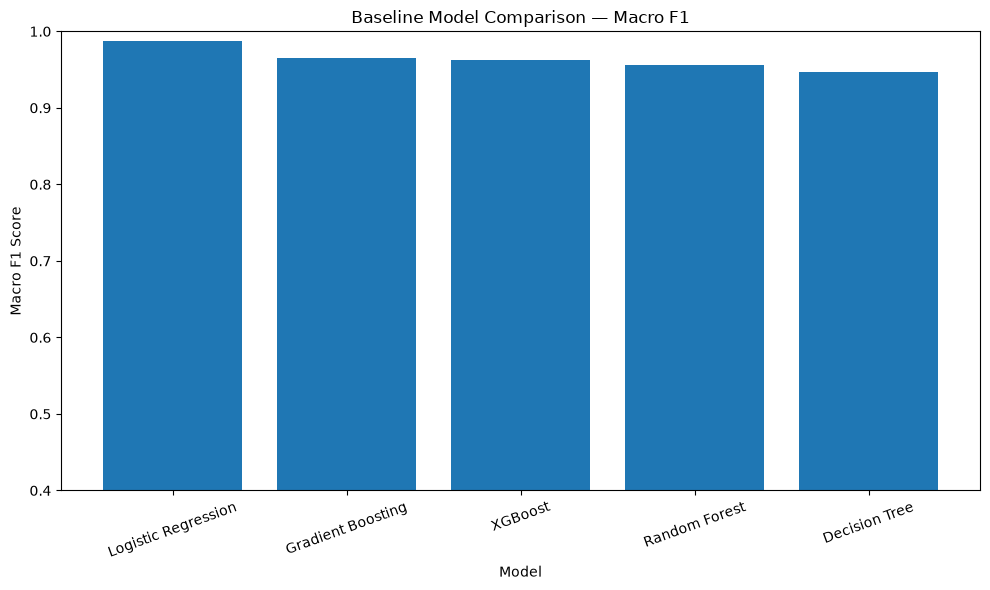

In [61]:
import matplotlib.pyplot as plt

model_comparison_df = pd.DataFrame(model_results)

# Keep only baseline models for the main comparison
baseline_comparison_df = model_comparison_df[
    model_comparison_df["Feature Set"] == "Baseline"
].copy()

# Sort by Macro F1
baseline_comparison_df = baseline_comparison_df.sort_values(
    by="Macro F1",
    ascending=False
)

print("=== BASELINE MODEL COMPARISON ===")
print(
    baseline_comparison_df[
        ["Model", "Accuracy", "Precision", "Recall", "Macro F1"]
    ].round(4)
)

plt.figure(figsize=(10, 6))

plt.bar(
    baseline_comparison_df["Model"],
    baseline_comparison_df["Macro F1"]
)

plt.ylabel("Macro F1 Score")
plt.xlabel("Model")
plt.title("Baseline Model Comparison — Macro F1")
plt.ylim(0.4, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

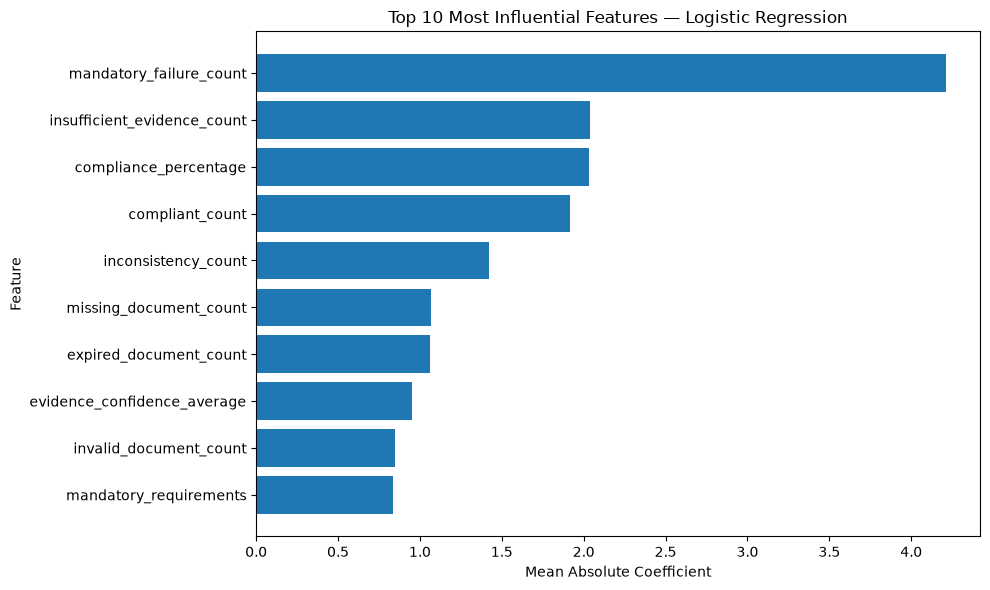

In [62]:
# ============================================================
# Top 10 Feature Importance Visualization
# ============================================================

top_10_features = feature_importance_df.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Mean_Absolute_Coefficient"][::-1]
)

plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features — Logistic Regression")
plt.tight_layout()

plt.show()

In [63]:
# ============================================================
# Final Model Artifact Verification
# ============================================================

from pathlib import Path
import joblib

model_path = Path("../models/bidguard_risk_model.joblib")
scaler_path = Path("../models/bidguard_risk_scaler.joblib")

print("=== MODEL ARTIFACT VERIFICATION ===")

print(f"Model file exists  : {model_path.exists()}")
print(f"Scaler file exists : {scaler_path.exists()}")

if model_path.exists() and scaler_path.exists():
    saved_model = joblib.load(model_path)
    saved_scaler = joblib.load(scaler_path)

    print(f"\nSaved model type   : {type(saved_model).__name__}")
    print(f"Saved scaler type  : {type(saved_scaler).__name__}")

    print(f"\nModel classes      : {saved_model.classes_}")
    print(f"Scaler features    : {saved_scaler.n_features_in_}")

    print("\nArtifact verification completed successfully.")
else:
    print("\nERROR: One or more model artifacts are missing.")

=== MODEL ARTIFACT VERIFICATION ===
Model file exists  : True
Scaler file exists : True

Saved model type   : LogisticRegression
Saved scaler type  : StandardScaler

Model classes      : ['HIGH' 'LOW' 'MEDIUM']
Scaler features    : 18

Artifact verification completed successfully.


In [64]:
# ============================================================
# Project Dependency Verification
# ============================================================

from pathlib import Path

requirements_path = Path("../requirements.txt")

print("=== REQUIREMENTS VERIFICATION ===")

if requirements_path.exists():
    requirements_text = requirements_path.read_text(
        encoding="utf-8"
    )

    print(requirements_text)

    print("\nXGBoost dependency present:",
          "xgboost" in requirements_text.lower())
else:
    print("ERROR: requirements.txt not found.")

=== REQUIREMENTS VERIFICATION ===


XGBoost dependency present: False


In [65]:
# ============================================================
# Project Dependency Version Check
# ============================================================

import sys
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import joblib
import xgboost

print("=== PROJECT DEPENDENCY VERSIONS ===")

print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {numpy.__version__}")
print(f"Pandas       : {pandas.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Seaborn      : {seaborn.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib       : {joblib.__version__}")
print(f"XGBoost      : {xgboost.__version__}")

ModuleNotFoundError: No module named 'seaborn'

In [66]:
# ============================================================
# Project Dependency Version Check
# ============================================================

import sys
from importlib.metadata import version, PackageNotFoundError

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib",
    "xgboost"
]

print("=== PROJECT DEPENDENCY VERSIONS ===")
print(f"Python : {sys.version.split()[0]}\n")

for package in packages:
    try:
        print(f"{package:<15}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package:<15}: NOT INSTALLED")

=== PROJECT DEPENDENCY VERSIONS ===
Python : 3.12.9

numpy          : 2.5.2
pandas         : 3.0.5
matplotlib     : 3.11.1
seaborn        : NOT INSTALLED
scikit-learn   : 1.9.0
joblib         : 1.6.0
xgboost        : 3.4.1


In [67]:
# ============================================================
# Project Import Dependency Check
# ============================================================

from pathlib import Path
import re

project_root = Path("..")

notebook_files = sorted(
    (project_root / "notebooks").glob("*.ipynb")
)

import_pattern = re.compile(
    r'^\s*(?:import|from)\s+([A-Za-z0-9_]+)',
    re.MULTILINE
)

found_imports = set()

for notebook in notebook_files:
    notebook_text = notebook.read_text(encoding="utf-8")

    imports = import_pattern.findall(notebook_text)

    for package in imports:
        found_imports.add(package)

print("=== IMPORTS FOUND IN PROJECT NOTEBOOKS ===")

for package in sorted(found_imports):
    print(package)

=== IMPORTS FOUND IN PROJECT NOTEBOOKS ===


In [68]:
# ============================================================
# Actual Notebook Import Dependency Check
# ============================================================

from pathlib import Path
import json
import re

notebooks_path = Path("../notebooks")

notebook_files = sorted(notebooks_path.glob("*.ipynb"))

found_imports = set()

for notebook_file in notebook_files:
    with open(notebook_file, "r", encoding="utf-8") as f:
        notebook_data = json.load(f)

    for cell in notebook_data.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        source = "".join(cell.get("source", []))

        for line in source.splitlines():
            line = line.strip()

            match_import = re.match(
                r"^(?:import|from)\s+([A-Za-z0-9_]+)",
                line
            )

            if match_import:
                found_imports.add(match_import.group(1))

print("=== ACTUAL IMPORTS FOUND IN PROJECT NOTEBOOKS ===")

for package in sorted(found_imports):
    print(package)

=== ACTUAL IMPORTS FOUND IN PROJECT NOTEBOOKS ===
matplotlib
numpy
pandas
pathlib
sklearn
xgboost


In [69]:
# ============================================================
# Final Requirements Verification
# ============================================================

from pathlib import Path

requirements_path = Path("../requirements.txt")

print("=== FINAL REQUIREMENTS.TXT ===")
print(requirements_path.read_text(encoding="utf-8"))

=== FINAL REQUIREMENTS.TXT ===

